In [1]:
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import FeatureUnion
from sklearn.preprocessing import FunctionTransformer
from torch import nn
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import torch.optim as optim

from features.extract_features import get_mel_spectrogram, get_mfcc
from models import DecisionTreeModel, LSTMModel
from utils import min_max_scaler, pad_audio
from denoise.denoise_methods import noise_reduce_denoise

c:\Users\josel\OneDrive\Desktop\NCIA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DCASE2024_ROOT_PATH = Path.cwd().parent / "data/raw/dcase-2024"

DCASE2024_TRAIN_PATH = DCASE2024_ROOT_PATH / "Train"
DCASE2024_DEV_PATH = DCASE2024_ROOT_PATH / "Dev"
DCASE2024_EVAL_PATH = DCASE2024_ROOT_PATH / "Eval"

DCASE2022_ROOT_PATH = Path.cwd().parent / "data/raw/dcase-2022"

DCASE2022_TRAIN_PATH = DCASE2022_ROOT_PATH / "Train"
DCASE2022_DEV_PATH = DCASE2022_ROOT_PATH / "Dev"

# ===============================================================
# ===============================================================

SAMPLE_RATE = 24_000

MEL_SPECTROGRAM_PARAMS = {
    "n_fft": 128,
    "sr": SAMPLE_RATE,
    "hop_length": 512,
    "window": "hann",
    "center": True,
    "pad_mode": "constant",
    "power": 2.0,
}

MFCC_PARAMS = {
    "sr": SAMPLE_RATE,
    "n_mfcc": 13,
    "dct_type": 2,
    "norm": "ortho",
    "lifter": 0,
}

In [3]:
def load_audio(audio):
    signal, sample_rate = librosa.load(audio, sr=SAMPLE_RATE)

    return signal, sample_rate

def get_features(signals):
    X_mel_spectrogram = []
    X_mfcc = []

    for signal in signals:
        mel = get_mel_spectrogram(signal, MEL_SPECTROGRAM_PARAMS)
        mfcc = get_mfcc(mel, MFCC_PARAMS)

        X_mel_spectrogram.append(mel)
        X_mfcc.append(mfcc)

    return X_mel_spectrogram, X_mfcc

# Leitura dos áudios


In [4]:
def read_dcase_dev_set(path, ignore_machine_types=[]):
    X_train = []
    X_test = []

    y_train = []
    y_test = []

    mtype_train = []
    mtype_test = []

    for machine_dir in Path(path).iterdir():
        if not machine_dir.is_dir():
            continue

        for section in ["train", "test"]:
            data_dir = machine_dir / section

            if not data_dir.exists() or machine_dir.name in ignore_machine_types:
                continue

            for audio_file in tqdm(data_dir.iterdir(), desc=f"Lendo {section}"):
                if audio_file.suffix != ".wav":
                    continue

                try:
                    signal, _ = load_audio(audio_file)

                    if "anomaly" in audio_file.name:
                        label = 1
                    else:
                        label = 0

                    if section == 'train':
                        X_train.append(signal)
                        y_train.append(label)
                        mtype_train.append(machine_dir.name)
                    else:
                        X_test.append(signal)
                        y_test.append(label)
                        mtype_test.append(machine_dir.name)

                except Exception as e:
                    print(f"Erro ao processar {audio_file.name}: {e}")

    return X_train, X_test, y_train, y_test, mtype_train, mtype_test


def read_dcase_train_set(path):
    X = []
    machine_type = []
    y = []

    for machine_dir in Path(path).iterdir():
        if not machine_dir.is_dir():
            continue

        data_dir = machine_dir / "train"
        if not data_dir.exists():
            continue

        for audio_file in tqdm(data_dir.iterdir(), desc="Lendo train"):
            if audio_file.suffix != ".wav":
                continue
            try:
                label = 0

                signal, _ = load_audio(audio_file)

                X.append(signal)
                machine_type.append(machine_dir.name)
                y.append(label)

            except Exception as e:
                print(f"Erro ao processar {audio_file.name}: {e}")

    return X, machine_type, y


def read_dcase_eval_set(path):
    X = []
    machine_type = []
    y = []

    for machine_dir in Path(path).iterdir():
        if not machine_dir.is_dir():
            continue

        data_dir = machine_dir / "test"
        if not data_dir.exists():
            continue

        for audio_file in tqdm(data_dir.iterdir(), desc="Lendo eval"):
            if audio_file.suffix != ".wav":
                continue
            try:
                if "anomaly" in audio_file.name:
                    label = 1
                else:
                    label = 0

                signal, _ = load_audio(audio_file)

                X.append(signal)
                machine_type.append(machine_dir.name)
                y.append(label)

            except Exception as e:
                print(f"Erro ao processar {audio_file.name}: {e}")

    return X, machine_type, y

In [ ]:
# Conjuntos que o artigo usa

# 25.199 áudios (treino e teste) - DCASE 2022/MIMII DG
#X_dcase22, mtypes_dcase22, y_dcase22 = read_dcase_dev_set(DCASE2022_DEV_PATH)

# # 9.000 áudios (treino) - DCASE 2024
# X_dcase24_train, mtypes_dcase24_train, y_dcase24_train = read_dcase_train_set(DCASE2024_TRAIN_PATH)

# # 1.800 áudios (teste) - DCASE 2024
# X_dcase24_test, mtypes_dcase24_test, y_dcase24_test = read_dcase_eval_set(DCASE2024_EVAL_PATH)

# # União do conjunto DCASE 2024
# X_dcase24 = X_dcase24_test + X_dcase24_train
# mtypes_dcase24 = mtypes_dcase24_test + mtypes_dcase24_train
# y_dcase24 = y_dcase24_test + y_dcase24_train

In [5]:
X_train, X_test, y_train, y_test, mtype_train, mtype_test = read_dcase_dev_set(DCASE2022_DEV_PATH, ignore_machine_types=['ToyCar', 'ToyTrain'])

print()
print('=' * 45)
print('Leitura Concluída!')
print(f'Total de amostras: {len(X_train) + len(X_test)}')
print(f'Amostras de treino: {len(X_train)}')
print(f'Amostras de testes: {len(X_test)}')
print(f'Máquinas de treino: {np.unique(mtype_train)}')
print(f'Máquinas de teste: {np.unique(mtype_test)}')
print('=' * 45)
print()

Lendo train: 2999it [01:19, 37.81it/s]
Lendo test: 600it [00:14, 40.24it/s]
Lendo train: 3000it [01:09, 43.33it/s]
Lendo test: 600it [00:13, 42.91it/s]
Lendo train: 3000it [01:06, 45.45it/s]
Lendo test: 600it [00:12, 46.47it/s]
Lendo train: 3000it [01:58, 25.36it/s]
Lendo test: 600it [00:20, 28.92it/s]
Lendo train: 3000it [01:45, 28.49it/s]
Lendo test: 600it [00:13, 45.93it/s]


Leitura Concluída!
Total de amostras: 17999
Amostras de treino: 14999
Amostras de testes: 3000
Máquinas de treino: ['bearing' 'fan' 'gearbox' 'slider' 'valve']
Máquinas de teste: ['bearing' 'fan' 'gearbox' 'slider' 'valve']



In [6]:
class AudioDataset(Dataset):
    def __init__(self, features, labels):
       self.features = features
       self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        feature = self.features[idx]
        label = self.labels[idx]

        return (torch.tensor(feature, dtype=torch.float32),
                torch.tensor(label, dtype=torch.long))

In [ ]:
def preprocess_data(signals, padding=False, desonise_method=None):
    mel_features = []
    mfcc_features = []

    for signal in signals:
        if padding:
            signal = pad_audio(signal)
        if desonise_method:
            signal = desonise_method(signal)
        
        mel = get_mel_spectrogram(signal, MEL_SPECTROGRAM_PARAMS)
        mfcc = get_mfcc(mel, MFCC_PARAMS)

        norm_mel = min_max_scaler(mel)
        norm_mfcc = min_max_scaler(mfcc) 

        mel_features.append(norm_mel)
        mfcc_features.append(norm_mfcc)

    return mel_features, mfcc_features

In [14]:
def train(model, optimizer, criterion, train_loader, epochs):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            X_batch = X_batch.transpose(1, 2)

            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        
        mean_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {mean_loss:.4f}")

def evaluate(model, data_loader, metric_fn, aggregate_fn=torch.mean):
    model.eval()
    metrics = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric = metric_fn(y_pred, y_batch)
            metrics.append(metric)
            
    return aggregate_fn(torch.stack(metrics))

In [ ]:
# denoise_method = lambda x : noise_reduce_denoise(x, SAMPLE_RATE)
denoise_method = None

train_mel, train_mfcc = preprocess_data(X_train, denoise_method)
test_mel, test_mfcc = preprocess_data(X_test, denoise_method)

train_mel, train_mfcc = torch.tensor(train_mel), torch.tensor(train_mfcc)
test_mel, test_mfcc = torch.tensor(test_mel), torch.tensor(test_mfcc)
 
lr = 0.0001
epochs = 30
features_set = 'mfcc'

if features_set == 'mel':
    train_features = train_mel
    test_features = test_mel
elif features_set == 'mfcc':
    train_features = train_mfcc
    test_features = test_mfcc
elif features_set == 'combine':
    train_features = torch.cat([train_mel, train_mfcc], dim=1)
    test_features = torch.cat([test_mel, test_mfcc], dim=1)

input_size = train_features[0].shape[0]

train_dataset = AudioDataset(train_features, y_train)
test_dataset = AudioDataset(test_features, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

model = LSTMModel(input_size)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

train(model, optimizer, criterion, train_loader, epochs)

Formato de um Mel-Spectrograma: torch.Size([128, 469])
Formato de um MFCC: torch.Size([13, 469])




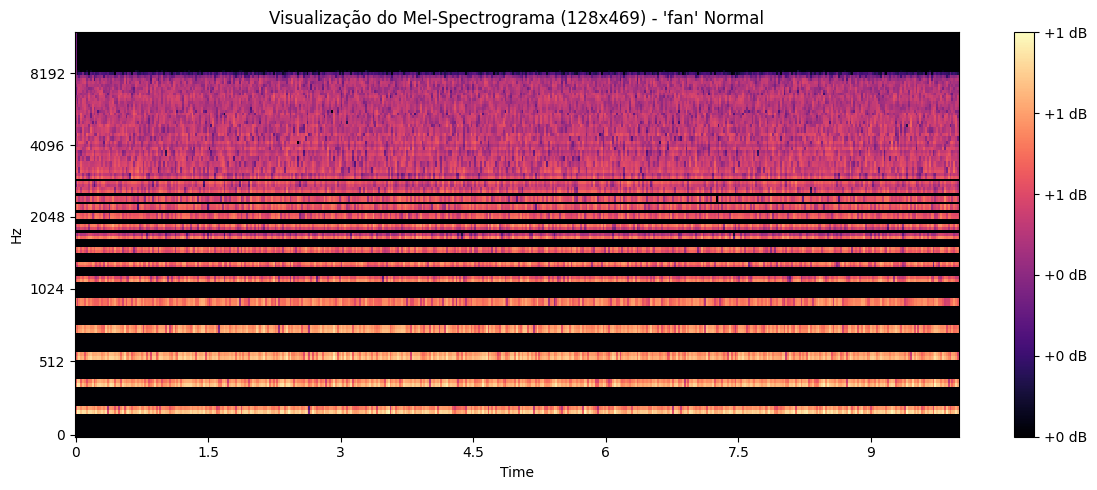

In [ ]:
i = 1000
mel, mfcc, label, mtype = test_dataset[i]

print(f"Formato de um Mel-Spectrograma: {mel.shape}")
print(f"Formato de um MFCC: {mfcc.shape}")

print()
print()

plt.figure(figsize=(12, 5))
librosa.display.specshow(mel.numpy(), sr=24000, hop_length=512, x_axis="time", y_axis="mel")

plt.colorbar(format="%+2.0f dB")
plt.title(f"Visualização do Mel-Spectrograma (128x469) - '{mtype}' {'Normal' if label else 'Anomalia'}")
plt.tight_layout()
plt.show()